### Your name:

<pre> Shamir Alavi</pre>

### Collaborators:

<pre> None </pre>


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Open the housing data


In [2]:
import os
import tarfile

HOUSING_PATH = os.path.join('..', 'data')

def fetch_housing_data(housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

# fetch_housing_data()

import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing_original = load_housing_data()
housing_original.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Build full pipeline for the data analysis following the example of the notebook.
 Hint: the main part requested to change is the algorithm used (KNN regression)


#### Considerations for building pipeline:

- Make your notebook as compact as possible. 
- Split data into training and testing sets below.
- Convert all categorical data to one-hot vectors below
- Normalize all non-categorical data 
-  Perform KNN regression using a variety of values for n_neighbors (K) between 1 and 10 and both "uniform" and "distance" weights via a grid search where  *housing_labels* is the output and all other features are the input (similar to as seen in lecture two.)

## Clean bad data
Looks like median house values, some median house values were capped to their nearest round number instead of keeping the original values. These are data artifacts we want to remove to keep the dataset clean. 

In [7]:
suspicious_values = [
    450000, 400000, 375000, 350000, 325000, 300000, 275000,
    250000, 225000, 200000, 187500, 175000, 162500, 150000,
    137500, 125000, 112500, 100000, 87500, 75000, 67500
]

housing = housing_original[
    ~housing_original["median_house_value"].isin(suspicious_values)
]

# Make sure there are no missing indices after removing rows
housing = housing.reset_index(drop=True)

housing.shape

(19330, 10)

## Create test set

### Stratify by household median income

In [8]:
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.0,4.5,6.,np.inf], labels=[1,2,3,4,5])

housing[['median_income', 'income_cat']].head()

,median_income,income_cat
0,8.3252,5
1,8.3014,5
2,7.2574,5
3,5.6431,4
4,3.8462,3


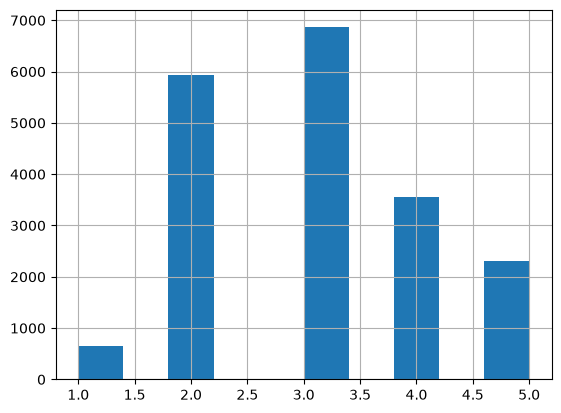

In [5]:
housing["income_cat"].hist()
plt.show()

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create dataset generator
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

## Training

In [ ]:
# Extract ONLY the training set 
housing = strat_train_set.copy()

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False);
plt.show()

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(15, 10))
plt.show()

In [ ]:
from matplotlib.ticker import MultipleLocator

housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, figsize=(10,10))
plt.axis([0, 16, 0, 510000])
plt.gca().yaxis.set_major_locator(MultipleLocator(25000))
plt.grid(True)
plt.show()

# Horizontal lines to remove
'''
450k
425k
350k
275k
225k
'''

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Write your code here:

In [ ]:
# Write your code here

### Conclusions
For what values of n_neighbors and weight does KNeighborsRegressor perform the best? Does it perform as well on the housing data as the linear regressor from the lectures? Why do you think this is?

<pre> WRITE RESPONSE HERE </pre>

### Read appending B

- Reflect on your last data project, read appendix B. Then, write down a few of the checklist items that your last data project could have used. If you have not yet done a data project, then write down a few of the items that you found most interesting.


### Submit your notebook

Submit your solution to Quercus
Make sure you rename your notebook to    
W2_UTORid.ipynb    
Example W2_adfasd01.ipynb
